In [1]:
# Вариант 1

products = {'Oranges (packaged)': 114.99, 'Candy (Rotfront)': 280.0, 'Boiled sausage': 199.99, 'Juice J7 (orange)': 119.99, 'Trout (Seven Seas)': 399.99}
stocks = {'Boiled sausage': '33%', 'Juice J7 (orange)': '12%', 'Trout (Seven Seas)': '18%'}

def apply_discounts(products, stocks):
    discount_dict = {}
    for element in products:
        
        if element in stocks.keys():
            base_price = products[element]
            discount = float(stocks[element].replace('%','')) / 100
            total = round(base_price - (base_price * discount),2)
            discount_dict[element] = total
        else:         
            discount_dict[element] = products[element]
    
    return discount_dict     
    


print(apply_discounts(products, stocks)) 

{'Oranges (packaged)': 114.99, 'Candy (Rotfront)': 280.0, 'Boiled sausage': 133.99, 'Juice J7 (orange)': 105.59, 'Trout (Seven Seas)': 327.99}


In [2]:
# Вариант 2

products = {'Oranges (packaged)': 114.99, 'Candy (Rotfront)': 280.0, 'Boiled sausage': 199.99, 'Juice J7 (orange)': 119.99, 'Trout (Seven Seas)': 399.99}
stocks = {'Boiled sausage': '33%', 'Juice J7 (orange)': '12%', 'Trout (Seven Seas)': '18%'}

def apply_discounts(products, stocks):
    discount_dict = {}
    for key, value in products.items():
        if key in stocks.keys():
            base_price = value
            discount = float(stocks[key].replace('%','')) / 100
            total = round(base_price - (base_price * discount),2)         
            discount_dict[key] = total
        else:         
            discount_dict[key] = products[key]
    
    return discount_dict

print(apply_discounts(products, stocks)) 

{'Oranges (packaged)': 114.99, 'Candy (Rotfront)': 280.0, 'Boiled sausage': 133.99, 'Juice J7 (orange)': 105.59, 'Trout (Seven Seas)': 327.99}


In [ ]:
import pandas as pd


Data_bronze = pd.read_csv('data/database.csv', sep=';')
display (Data_bronze.head())

Data_silver = pd.read_csv('data/database.csv', sep=';')
display (Data_silver.head())

merged = Data_bronze.join(
    Data_silver.set_index('Country'),
    on='Country',
    lsuffix='Total_bronze',
    rsuffix='Total_silver',
    how='inner'
)
merged = merged.drop(['Total', 'Coordinates'], axis=1)


display(merged)

In [ ]:
import pandas as pd


Data_bronze = pd.read_csv('data/database.csv', sep=';')
display (Data_bronze.head())

Data_silver = pd.read_csv('data/database.csv', sep=';')
display (Data_silver.head())

merged = Data_bronze.merge(
    Data_silver,
    on='Country',
    how='inner'
)


>>> df = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6]})
>>> merged.rename(columns={"A": "Total_bronze", "B": "Total_silver"})
   a  c
0  1  4
1  2  5
2  3  6



display(merged.head())

In [3]:
import pandas as pd
import numpy as np

Solar_data = pd.read_csv('data/solarpower.csv', sep=',')

display (Solar_data.info())
display ('Дата', Solar_data.head())
print ('Среднеарифметическое базовое:', Solar_data['cum_power'].mean())
display ('Узнаем какие индексы == -1', Solar_data[Solar_data['cum_power'] == -1])
Solar_data[Solar_data['cum_power'] == -1].index

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       664 non-null    object 
 1   cum_power  664 non-null    float64
dtypes: float64(1), object(1)
memory usage: 10.5+ KB


None

'Дата'

,date,cum_power
0,2017-01-01,20111.0
1,2017-01-02,20112.0
2,2017-01-03,20115.0
3,2017-01-04,20117.0
4,2017-01-05,20119.0


Среднеарифметическое базовое: 23775.573795180724


'Узнаем какие индексы == -1'

,date,cum_power
45,2017-02-15,-1.0
647,2018-10-10,-1.0


Index([45, 647], dtype='int64')

In [ ]:
z = Solar_data.cum_power
display (z)

In [ ]:
Solar_data_1 = Solar_data.copy()

def new (data,cum_power):
    z = len(Solar_data_1['cum_power'])
    for i in range(z):
        if Solar_data_1['cum_power'][i]== -1:
            a = (Solar_data_1['cum_power'][i-1] + Solar_data_1['cum_power'][i+1]) / 2
            #print (a)
            Solar_data_1['cum_power'][i] = a
        else:
            b = Solar_data_1['cum_power'][i]
            Solar_data_1['cum_power'][i] = b
    return Solar_data_1       

Solar_data_1 = new(Solar_data_1,'cum_power')

print (round(Solar_data_1['cum_power'].mean(),2))

Solar_data_1[Solar_data_1['cum_power'] == -1].shape

C:\Users\Home\AppData\Local\Temp\ipykernel_12100\2188951326.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Solar_data_1['cum_power'][i] = b
C:\Users\Home\AppData\Local\Temp\ipykernel_12100\2188951326.py:12: SettingWithCopyWarning: 
A v

20255.0


C:\Users\Home\AppData\Local\Temp\ipykernel_12100\2188951326.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Solar_data_1['cum_power'][i] = b
C:\Users\Home\AppData\Local\Temp\ipykernel_12100\2188951326.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a 

27998.0
23848.25


C:\Users\Home\AppData\Local\Temp\ipykernel_12100\2188951326.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Solar_data_1['cum_power'][i] = b
C:\Users\Home\AppData\Local\Temp\ipykernel_12100\2188951326.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a 

(0, 2)

In [4]:
# Вриант 2 - Продвинутый - сокращенный

Solar_data_2 = Solar_data.copy()

def new (data,cum_power):
    z = len(Solar_data_2['cum_power'])
    for i in range(z):
        if Solar_data_2.loc[i,'cum_power'] == -1:
            a = (float(Solar_data_2.loc[i-1,'cum_power']) + float(Solar_data_2.loc[i+1,'cum_power'])) / 2 # float - для тренировки
            Solar_data_2.loc[i,'cum_power'] = a
    return Solar_data_2       


Solar_data_2 = new(Solar_data_2,'cum_power')
print (round(Solar_data_2['cum_power'].mean()))

Solar_data_2[Solar_data_2['cum_power'] == -1].shape

23848


(0, 2)

In [6]:
# Вриант 3 - Продвинутый

Solar_data_3 = Solar_data.copy()

def new (data,cum_power):
    z = len(Solar_data_3['cum_power'])
    for i in range(z):
        if Solar_data_3.loc[i,'cum_power'] == -1:
            variable_1 = Solar_data_2.loc[i-1,'cum_power']
            variable_2 = Solar_data_2.loc[i+1,'cum_power']
            a = Solar_data_2.loc[i,'cum_power'] = (variable_1 + variable_2) / 2
            #print (a)
        else:
            #b = Solar_data_2.loc[i,'cum_power']
            #print (b)
            Solar_data_2.loc[i,'cum_power'] = Solar_data_2.loc[i,'cum_power']
    #print (Solar_data_1.count())
    # print (Solar_data_1['cum_power'].mean())
    return Solar_data_2       


Solar_data_2 = new(Solar_data_2,'cum_power')
print (round(Solar_data_2['cum_power'].mean(),))

Solar_data_2[Solar_data_2['cum_power'] == -1].shape

23848


(0, 2)

In [5]:
import pandas as pd

solar_data = pd.read_csv("data/solarpower.csv", sep=",")
solar_data_777 = solar_data.copy()

for i in range(len(solar_data_777)):
    if solar_data_777.at[i, 'cum_power'] == -1:
        solar_data_777.at[i, 'cum_power'] = (float(solar_data_777.at[i - 1, 'cum_power']) + float(solar_data_777.at[i + 1, 'cum_power'])) / 2 # float - для тренировки
        print("Пересчет значения по индексу", i, "Предыдущее значение:", solar_data_777.at[i - 1, 'cum_power'], ", значение после: ", solar_data_777.at[i + 1, 'cum_power'], ", среднее:", solar_data_777.at[i, 'cum_power'])

    #print(i, "-", solar_data.values[i])

print (round(solar_data_777['cum_power'].mean()))
#solar_data_777[solar_data_777['cum_power'] == -1].index

Пересчет значения по индексу 45 Предыдущее значение: 20248.0 , значение после:  20262.0 , среднее: 20255.0
Пересчет значения по индексу 647 Предыдущее значение: 27986.0 , значение после:  28010.0 , среднее: 27998.0
23848


In [7]:
Solar_data_3 = Solar_data_2.copy()

Solar_data_3['day_power'] = Solar_data_3['cum_power']
#Solar_data_3['day_power'] = float(round(0))
#Solar_data_3['day_power'] = str('')
display (Solar_data_3.head(5))
display (Solar_data_3.info())


,date,cum_power,day_power
0,2017-01-01,20111.0,20111.0
1,2017-01-02,20112.0,20112.0
2,2017-01-03,20115.0,20115.0
3,2017-01-04,20117.0,20117.0
4,2017-01-05,20119.0,20119.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 664 entries, 0 to 663
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       664 non-null    object 
 1   cum_power  664 non-null    float64
 2   day_power  664 non-null    float64
dtypes: float64(2), object(1)
memory usage: 15.7+ KB


None

In [9]:
Solar_data_3['new_date'] = pd.to_datetime(Solar_data_3['date'])
#display(Solar_data_3['new_date'])

Solar_data_3['years_date'] = Solar_data_3['new_date'].dt.year
print(Solar_data_3['years_date'].count())

Solar_data_3['months_date'] = Solar_data_3['new_date'].dt.month
print (Solar_data_3['months_date'].head())

664
0    1
1    1
2    1
3    1
4    1
Name: months_date, dtype: int32


In [15]:
Solar_data_3.head()
#Solar_data_3.info()

,date,cum_power,day_power,new_date,years_date,months_date
0,2017-01-01,20111.0,20111.0,2017-01-01,2017,1
1,2017-01-02,20112.0,20112.0,2017-01-02,2017,1
2,2017-01-03,20115.0,20115.0,2017-01-03,2017,1
3,2017-01-04,20117.0,20117.0,2017-01-04,2017,1
4,2017-01-05,20119.0,20119.0,2017-01-05,2017,1


In [ ]:
print (round(Solar_data_3[Solar_data_3['years_date'] == 2017].groupby('months_date')['day_power'].mean(),))
#Solar_data_3[Solar_data_3['years_date'] == 2017].groupby('months_date')['day_power'].mean()

months_date
1     20153.0
2     20257.0
3     20445.0
4     20885.0
5     21408.0
6     22068.0
7     22667.0
8     23179.0
9     23573.0
10    23858.0
11    23999.0
12    24059.0
Name: day_power, dtype: float64


In [12]:
Solar_data_3.groupby(['months_date', 'years_date'])['day_power'].mean()

months_date  years_date
1            2017          20153.096774
             2018          24103.516129
2            2017          20257.035714
             2018          24225.321429
3            2017          20444.580645
             2018          24461.258065
4            2017          20885.033333
             2018          24815.300000
5            2017          21408.096774
             2018          25387.096774
6            2017          22068.233333
             2018          25959.300000
7            2017          22667.096774
             2018          26625.483871
8            2017          23178.677419
             2018          27245.322581
9            2017          23573.433333
             2018          27692.100000
10           2017          23858.322581
             2018          28024.230769
11           2017          23999.166667
12           2017          24058.516129
Name: day_power, dtype: float64

In [11]:
Solar_data_3.groupby(['years_date', 'months_date'])['day_power'].mean().round()

years_date  months_date
2017        1              20153.0
            2              20257.0
            3              20445.0
            4              20885.0
            5              21408.0
            6              22068.0
            7              22667.0
            8              23179.0
            9              23573.0
            10             23858.0
            11             23999.0
            12             24059.0
2018        1              24104.0
            2              24225.0
            3              24461.0
            4              24815.0
            5              25387.0
            6              25959.0
            7              26625.0
            8              27245.0
            9              27692.0
            10             28024.0
Name: day_power, dtype: float64

In [34]:
import plotly
import plotly.express as px

a = Solar_data_3.groupby(
    ['months_date', 'years_date'],
    as_index=False
    )['day_power'].mean()

fig = px.bar(
    data_frame=a,
    x='years_date',
    y='day_power', 
    color='months_date',
    orientation='v',
    height=500, 
    width=1000,
    barmode="group",
    title='xxx'
)
fig.show()

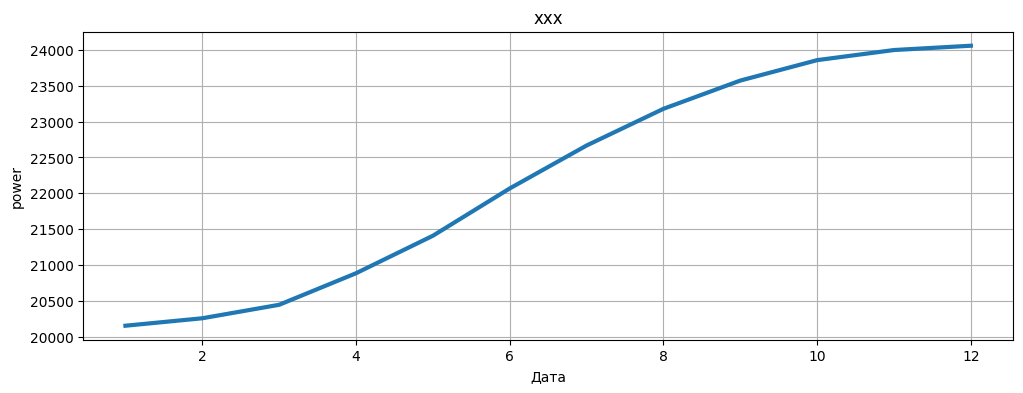

In [129]:


Solar_data_3[Solar_data_3['years_date'] == 2017].groupby('months_date')['day_power'].mean().round().plot(
    kind='line',
    figsize=(12, 4),
    title='xxx',
    xlabel='Дата',
    ylabel='power',
    grid = True,
    lw=3 # !!!!!   ВАЖНО - это толщина линии   !!!!!!!!!!!!!!!!!
    );

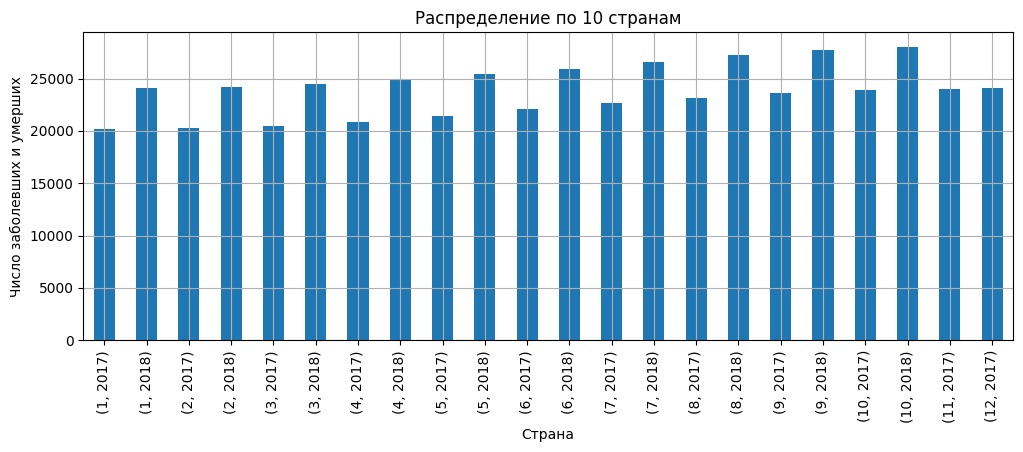

In [131]:
Solar_data_3.groupby(['months_date', 'years_date'])['day_power'].mean().round().plot(
    kind='bar',
    title='Распределение по 10 странам',
    xlabel='Страна',
    ylabel='Число заболевших и умерших',
    grid=True,
    figsize=(12, 4),
    );

In [91]:
Solar_data_3.groupby(['years_date'])['day_power'].mean()

years_date
2017    22224.090411
2018    25830.913043
Name: day_power, dtype: float64

In [92]:
Solar_data_3.groupby(['months_date'])['day_power'].mean()

months_date
1     22128.306452
2     22241.178571
3     22452.919355
4     22850.166667
5     23397.596774
6     24013.766667
7     24646.290323
8     25212.000000
9     25632.766667
10    25758.561404
11    23999.166667
12    24058.516129
Name: day_power, dtype: float64

In [10]:
round(Solar_data_3.pivot_table(
    values=['day_power'],
    index=['years_date'],
    columns=['months_date'],
    aggfunc=['mean'],
),)

mean                                                        \
            day_power                                                         
months_date        1        2        3        4        5        6        7    
years_date                                                                    
2017          20153.0  20257.0  20445.0  20885.0  21408.0  22068.0  22667.0   
2018          24104.0  24225.0  24461.0  24815.0  25387.0  25959.0  26625.0   

                                                          
                                                          
months_date       8        9        10       11       12  
years_date                                                
2017         23179.0  23573.0  23858.0  23999.0  24059.0  
2018         27245.0  27692.0  28024.0      NaN      NaN